<a href="https://colab.research.google.com/github/nguyentrongnguyen3004-eng/Th_Deep_Learning/blob/main/TH_DeepLearning_B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CNN**

**2.1 Nạp thư viện**

In [ ]:
# Xử lý dữ liệu
import pandas as pd
import numpy as np

# Xây dựng CNN
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input

# Vẽ ảnh và đồ thị
import matplotlib.pyplot as plt

**2.2 Đọc dữ liệu MNIST**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
mnist_train = '/content/drive/MyDrive/Data_DeepLearning/mnist_train.csv'
mnist_test = '/content/drive/MyDrive/Data_DeepLearning/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# Ảnh MNIST có kích thước 28 x 28, nên mỗi ảnh có 784 giá trị pixel

(59999, 785)
(59999, 784) (59999,) (9999, 784) (9999,)


In [ ]:
# Tiền xử lý dữ liệu
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(59999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    0
1    4
2    1
3    9
4    2
Name: 5, dtype: int64


**2.3. Trực quan hóa 10 ảnh đầu tiên**

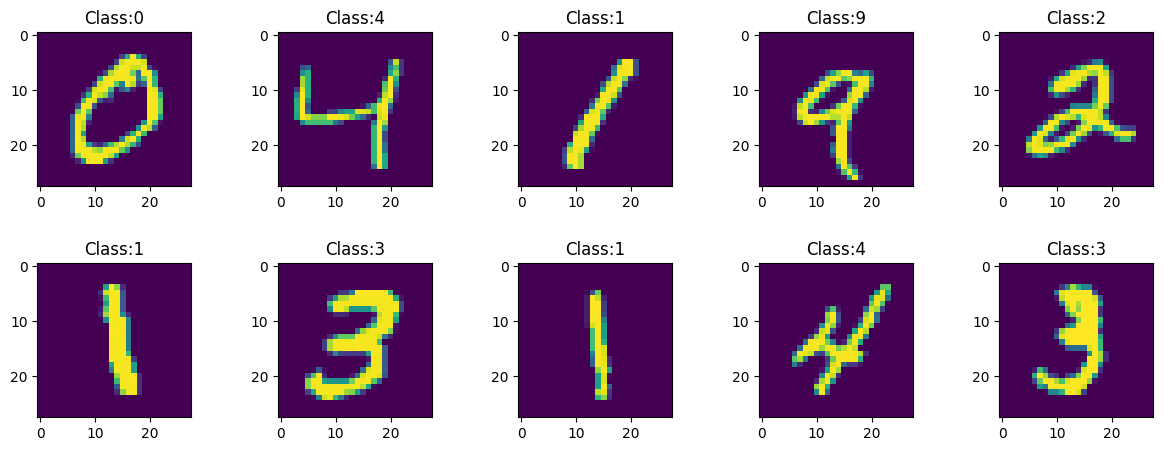

In [ ]:
# Hiển thị 10 ảnh đầu tiên trong tập train
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    # Chuyển ảnh từ dạng ma trận có kênh màu về ảnh 2 chiều
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
    plt.subplots_adjust(hspace=0.5)
plt.show()

**2.4. Chuyển giá trị nhãn thành one-hot encoding**

In [ ]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

**2.5. Xây dựng mô hình CNN**

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

# Chuyển dữ liệu về vector 1 chiều
model.add(Flatten())

# Hàm softmax dùng để phân loại đa lớp
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

**2.6. Huấn luyện mô hình CNN**

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Mô hình học 15 vòng và lấy 10% dữ liệu train để làm tập validation
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 48s 108ms/step - accuracy: 0.9167 - loss: 0.2967 - val_accuracy: 0.9743 - val_loss: 0.0869
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 78s 100ms/step - accuracy: 0.9768 - loss: 0.0778 - val_accuracy: 0.9845 - val_loss: 0.0586
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 109ms/step - accuracy: 0.9828 - loss: 0.0562 - val_accuracy: 0.9865 - val_loss: 0.0487
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 122ms/step - accuracy: 0.9849 - loss: 0.0473 - val_accuracy: 0.9892 - val_loss: 0.0427
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 109ms/step - accuracy: 0.9878 - loss: 0.0396 - val_accuracy: 0.9872 - val_loss: 0.0472
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 49s 115ms/step - accuracy: 0.9889 - loss: 0.0349 - val_accuracy: 0.9875 - val_loss: 0.0401
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 112ms/step - accuracy: 0.9907 - loss: 0.0296 - val_accuracy: 0.9895 - val_loss: 0.0360
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 48s 114ms/step - accuracy: 0.9918 - loss: 0

**2.7. Đánh giá mô hình CNN bằng biểu đồ accuracy**

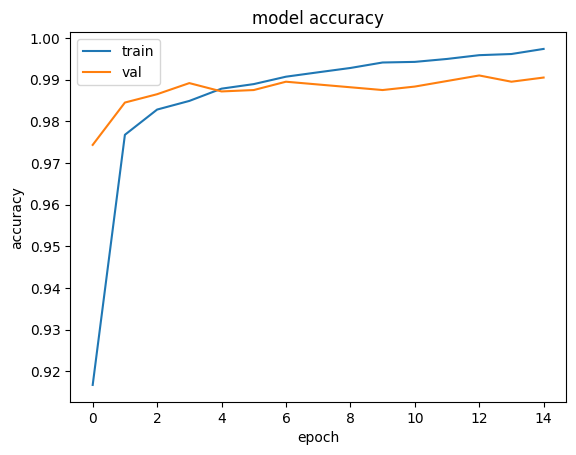

In [ ]:
# So sánh độ chính xác trên tập train và calidation qua từng epoch
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

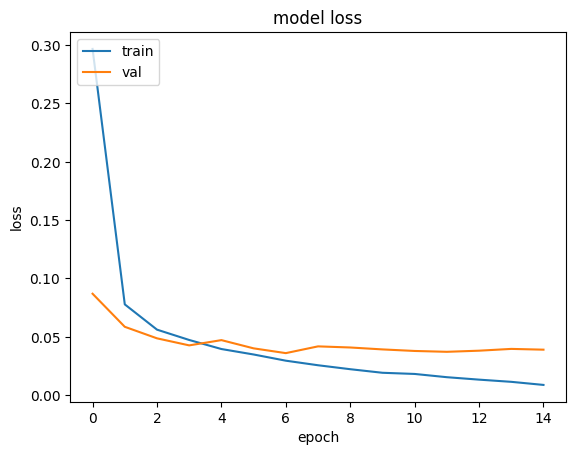

In [ ]:
# Vẽ biểu đồ loss, thể hiện giá trị mất mát của mô hình
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

**2.8. Đánh giá mô hình CNN thử nghiệm trên tập test**

In [ ]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 8ms/step - accuracy: 0.9901 - loss: 0.0349
Test loss: 0.034875787794589996
Test accuracy: 0.9900990128517151


**2.9. Dự báo nhãn cho ảnh sử dụng CNN**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
[[1.6867914e-09 9.8510422e-10 9.9999988e-01 3.4192736e-13 6.4490754e-16
  2.8059801e-16 1.5540461e-07 6.2092480e-12 4.8005409e-09 2.7374611e-14]]
2 2


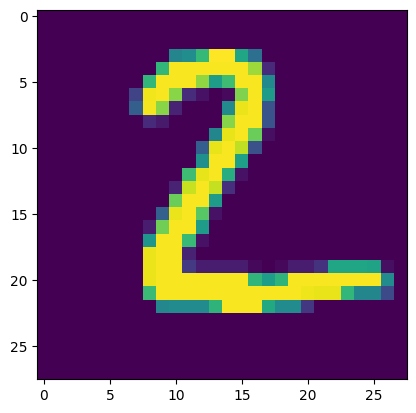

In [ ]:
# Dự đoán xác suất ảnh thuộc từng lớp
predict = model.predict(X_test[:1])
print(predict)

# Lấy vị trí có xác suất cao nhất
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

**2.10. Lưu tham số mô hình CNN**

In [ ]:
model.save_weights('cnn.weights.h5')

**2.11. Nạp lại mô hình và tham số**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
[[8.12732714e-10 9.99907970e-01 7.42082946e-08 1.95251273e-10
  3.05208378e-05 1.31698625e-08 1.88346849e-08 5.92639408e-05
  2.12062992e-06 2.23040630e-09]]
1 1


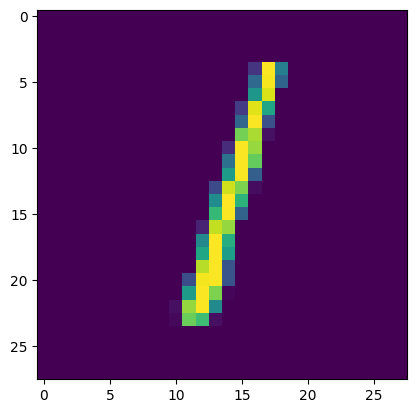

In [ ]:
# Nạp lại mô hình và có thể dự đoán mà không cần train lại
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

**BÀI TẬP**

**BÀI TẬP 1: CNN nhận dạng ảnh CIFAR10**

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 94ms/step - accuracy: 0.3687 - loss: 1.7126 - val_accuracy: 0.5086 - val_loss: 1.3570
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 92ms/step - accuracy: 0.5135 - loss: 1.3613 - val_accuracy: 0.5982 - val_loss: 1.1472
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.5782 - loss: 1.1976 - val_accuracy: 0.6312 - val_loss: 1.0362
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 90ms/step - accuracy: 0.6155 - loss: 1.0914 - val_accuracy: 0.6808 - val_loss: 0.9306
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 90ms/step - accuracy: 0.6475 - loss: 1.0088 - val_accuracy: 0.6890 - val_loss: 0.8962
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 91ms/step - accuracy: 0.6768 - loss: 0.9361 - val_accuracy: 0.6948 - val_loss: 0.8856
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.6961 - loss: 0.8772 - val_accuracy: 0.7240 - val_loss: 0.8217
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 92ms/step - accuracy: 0.7131 - loss: 0.8243 - 

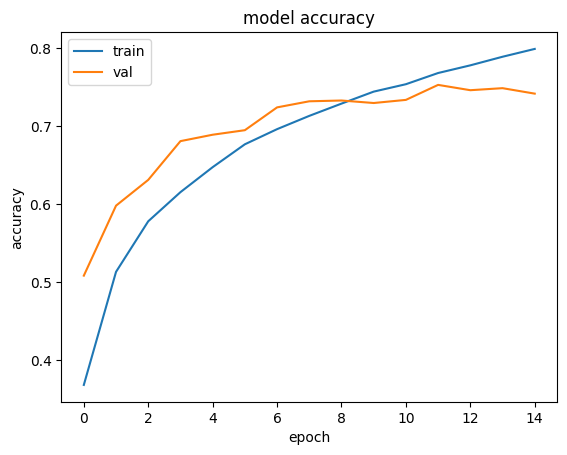

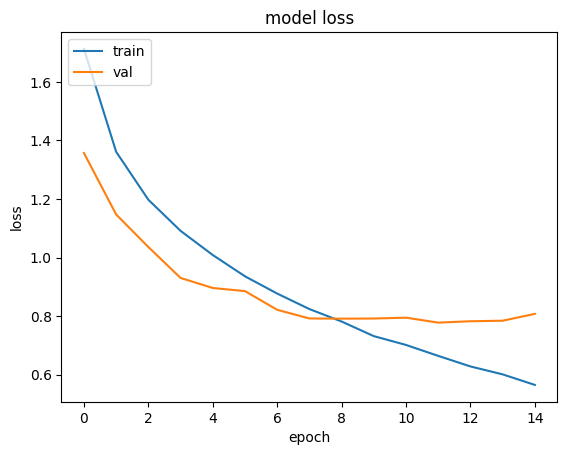

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
Predicted: cat
True: cat


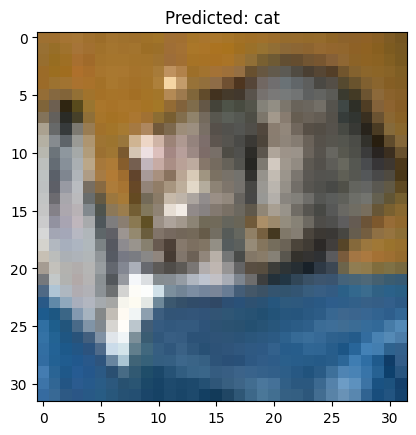

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input
from keras.datasets import cifar10

# 1. Đọc dữ liệu CIFAR10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# 2. Khai báo tên lớp
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 3. Chuẩn hóa dữ liệu ảnh
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# 4. One-hot encoding nhãn
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# 5. Xây dựng mô hình CNN
model = Sequential()
model.add(Input(shape=(32, 32, 3)))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(128, kernel_size=(3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()

# 6. Compile mô hình
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 7. Huấn luyện mô hình
model_fit = model.fit(X_train, y_train,
                      batch_size=64,
                      epochs=15,
                      validation_split=0.1,
                      verbose=1)

# 8. Đánh giá mô hình
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# 9. Vẽ biểu đồ accuracy
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# 10. Vẽ biểu đồ loss
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# 11. Dự đoán thử 1 ảnh
predict = model.predict(X_test[:1])
predicted_label = np.argmax(predict)
true_label = np.argmax(y_test[0])

print('Predicted:', class_names[predicted_label])
print('True:', class_names[true_label])

plt.imshow(X_test[0])
plt.title('Predicted: ' + class_names[predicted_label])
plt.show()

**Bài 2. CNN nhận dạng Cat hoặc Dog**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Kiểm tra file trong Google Drive
import os

drive_folder = '/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat'

print(os.listdir(drive_folder))

['test.zip', 'train.zip', 'dogs_vs_cats']


In [ ]:
# Giải nén train.zip
import zipfile
import os

zip_path = '/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/train.zip'
extract_path = '/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/dogs_vs_cats'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

In [ ]:
# Giải nén test.zip
import zipfile
import os

zip_path = '/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/test.zip'
extract_path = '/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/dogs_vs_cats'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['train', 'test']


In [ ]:
# Kiểm tra thư mục ảnh train
source_dir = '/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/dogs_vs_cats/train'

print(os.listdir(source_dir)[:10])
print('Tổng số ảnh:', len(os.listdir(source_dir)))

['dog.9099.jpg', 'dog.91.jpg', 'dog.910.jpg', 'dog.9100.jpg', 'dog.9101.jpg', 'dog.9102.jpg', 'dog.9103.jpg', 'dog.9104.jpg', 'dog.9105.jpg', 'dog.9106.jpg']
Tổng số ảnh: 25000


In [ ]:
# Kiểm tra thư mục ảnh test
source_dir = '/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/dogs_vs_cats/test'

print(os.listdir(source_dir)[:10])
print('Tổng số ảnh:', len(os.listdir(source_dir)))

['9099.jpg', '91.jpg', '910.jpg', '9100.jpg', '9101.jpg', '9102.jpg', '9103.jpg', '9104.jpg', '9105.jpg', '9106.jpg']
Tổng số ảnh: 12500


In [3]:
# Tách ảnh Cat/Dog thành thư mục train/test
import os
import shutil
from sklearn.model_selection import train_test_split

source_dir = '/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/dogs_vs_cats/train'

base_dir = '/content/dataset_dogs_vs_cats'

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
test_cats_dir = os.path.join(test_dir, 'cats')
test_dogs_dir = os.path.join(test_dir, 'dogs')

os.makedirs(train_cats_dir, exist_ok=True)
os.makedirs(train_dogs_dir, exist_ok=True)
os.makedirs(test_cats_dir, exist_ok=True)
os.makedirs(test_dogs_dir, exist_ok=True)

cat_files = [f for f in os.listdir(source_dir) if f.startswith('cat')]
dog_files = [f for f in os.listdir(source_dir) if f.startswith('dog')]

cat_train, cat_test = train_test_split(cat_files, test_size=0.2, random_state=42)
dog_train, dog_test = train_test_split(dog_files, test_size=0.2, random_state=42)

for file in cat_train:
    shutil.copy(os.path.join(source_dir, file), os.path.join(train_cats_dir, file))

for file in cat_test:
    shutil.copy(os.path.join(source_dir, file), os.path.join(test_cats_dir, file))

for file in dog_train:
    shutil.copy(os.path.join(source_dir, file), os.path.join(train_dogs_dir, file))

for file in dog_test:
    shutil.copy(os.path.join(source_dir, file), os.path.join(test_dogs_dir, file))

print('Số ảnh cat train:', len(os.listdir(train_cats_dir)))
print('Số ảnh dog train:', len(os.listdir(train_dogs_dir)))
print('Số ảnh cat test:', len(os.listdir(test_cats_dir)))
print('Số ảnh dog test:', len(os.listdir(test_dogs_dir)))

Số ảnh cat train: 10000
Số ảnh dog train: 10000
Số ảnh cat test: 2500
Số ảnh dog test: 2500


In [4]:
# Train CNN Cat/Dog
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = '/content/dataset_dogs_vs_cats/train'
test_dir = '/content/dataset_dogs_vs_cats/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

model = Sequential()
model.add(Input(shape=(150, 150, 3)))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(128, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_fit = model.fit(
    train_data,
    epochs=15,
    validation_data=test_data
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1082s 2s/step - accuracy: 0.6237 - loss: 0.6361 - val_accuracy: 0.7428 - val_loss: 0.5552
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1074s 2s/step - accuracy: 0.7394 - loss: 0.5275 - val_accuracy: 0.7888 - val_loss: 0.4567
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1069s 2s/step - accuracy: 0.7770 - loss: 0.4737 - val_accuracy: 0.7812 - val_loss: 0.4939
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1077s 2s/step - accuracy: 0.7995 - loss: 0.4339 - val_accuracy: 0.8242 - val_loss: 0.4001
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1052s 2s/step - accuracy: 0.8136 - loss: 0.4087 - val_accuracy: 0.8358 - val_loss: 0.3759
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1064s 2s/step - accuracy: 0.8319 - loss: 0.3776 - val_accuracy: 0.8492 - val_loss: 0.3464
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1058s 2s/step - accuracy: 0.8430 - loss: 0.3586 - val_accuracy: 0.8610 - val_loss: 0.3274
Epoch 8/15
223/625 ━━━━━━━━━━━━━━━━━━━━ 10:36 2s/step - accuracy: 0.8576 - loss: 0.3322

KeyboardInterrupt: 

In [5]:
model.save('/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/cat_dog_cnn_resume.keras')

In [13]:
# Train tiếp
import os

model_path = '/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/cat_dog_cnn_resume.keras'

print(os.path.exists(model_path))

True


In [14]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/train.zip'
extract_path = '/content/dogs_vs_cats'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['train']


In [15]:
source_dir = '/content/dogs_vs_cats/train'

print(os.listdir(source_dir)[:10])
print('Tổng số ảnh:', len(os.listdir(source_dir)))

['dog.742.jpg', 'dog.8779.jpg', 'dog.5520.jpg', 'dog.11844.jpg', 'dog.11483.jpg', 'cat.5053.jpg', 'cat.1352.jpg', 'dog.3116.jpg', 'cat.6701.jpg', 'dog.7762.jpg']
Tổng số ảnh: 25000


In [16]:
import os
import shutil
from sklearn.model_selection import train_test_split

source_dir = '/content/dogs_vs_cats/train'

base_dir = '/content/dataset_dogs_vs_cats'

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
test_cats_dir = os.path.join(test_dir, 'cats')
test_dogs_dir = os.path.join(test_dir, 'dogs')

os.makedirs(train_cats_dir, exist_ok=True)
os.makedirs(train_dogs_dir, exist_ok=True)
os.makedirs(test_cats_dir, exist_ok=True)
os.makedirs(test_dogs_dir, exist_ok=True)

cat_files = [f for f in os.listdir(source_dir) if f.startswith('cat')]
dog_files = [f for f in os.listdir(source_dir) if f.startswith('dog')]

cat_train, cat_test = train_test_split(cat_files, test_size=0.2, random_state=42)
dog_train, dog_test = train_test_split(dog_files, test_size=0.2, random_state=42)

for file in cat_train:
    shutil.copy(os.path.join(source_dir, file), os.path.join(train_cats_dir, file))

for file in cat_test:
    shutil.copy(os.path.join(source_dir, file), os.path.join(test_cats_dir, file))

for file in dog_train:
    shutil.copy(os.path.join(source_dir, file), os.path.join(train_dogs_dir, file))

for file in dog_test:
    shutil.copy(os.path.join(source_dir, file), os.path.join(test_dogs_dir, file))

print('Số ảnh cat train:', len(os.listdir(train_cats_dir)))
print('Số ảnh dog train:', len(os.listdir(train_dogs_dir)))
print('Số ảnh cat test:', len(os.listdir(test_cats_dir)))
print('Số ảnh dog test:', len(os.listdir(test_dogs_dir)))

Số ảnh cat train: 10000
Số ảnh dog train: 10000
Số ảnh cat test: 2500
Số ảnh dog test: 2500


In [17]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = '/content/dataset_dogs_vs_cats/train'
test_dir = '/content/dataset_dogs_vs_cats/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [18]:
model = keras.models.load_model(
    '/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/cat_dog_cnn_resume.keras'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,485,445 (55.26 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,656,964 (36.84 MB)

In [19]:
model_fit = model.fit(
    train_data,
    epochs=15,
    initial_epoch=7,
    validation_data=test_data
)

Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1180s 2s/step - accuracy: 0.8515 - loss: 0.3411 - val_accuracy: 0.8788 - val_loss: 0.2901
Epoch 9/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1185s 2s/step - accuracy: 0.8602 - loss: 0.3269 - val_accuracy: 0.8772 - val_loss: 0.2821
Epoch 10/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1171s 2s/step - accuracy: 0.8644 - loss: 0.3163 - val_accuracy: 0.8888 - val_loss: 0.2642
Epoch 11/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1159s 2s/step - accuracy: 0.8691 - loss: 0.3045 - val_accuracy: 0.8562 - val_loss: 0.3353
Epoch 12/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1154s 2s/step - accuracy: 0.8776 - loss: 0.2917 - val_accuracy: 0.8948 - val_loss: 0.2532
Epoch 13/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1163s 2s/step - accuracy: 0.8808 - loss: 0.2821 - val_accuracy: 0.8990 - val_loss: 0.2565
Epoch 14/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1174s 2s/step - accuracy: 0.8867 - loss: 0.2700 - val_accuracy: 0.8816 - val_loss: 0.2866
Epoch 15/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1174s 2s/step - accuracy: 0.8865 - loss: 0.2

In [20]:
# Đánh giá mô hình
score = model.evaluate(test_data)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 484ms/step - accuracy: 0.8872 - loss: 0.2689
Test loss: 0.2688911259174347
Test accuracy: 0.8871999979019165


In [21]:
# Lưu model ngược lại vào Google Drive
model.save('/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/cat_dog_cnn.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Dự đoán: Dog


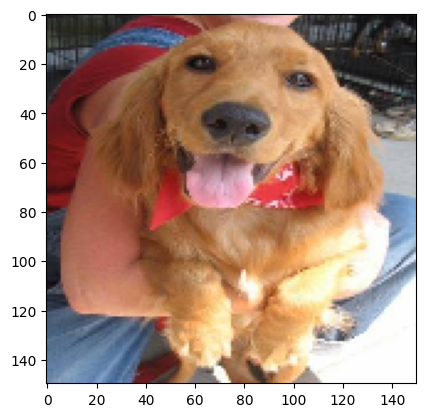

In [25]:
# Dự đoán thử một ảnh
import numpy as np
from keras.preprocessing import image
import matplotlib.pyplot as plt
import os

dog_folder = '/content/dataset_dogs_vs_cats/test/dogs'
img_name = os.listdir(dog_folder)[2]
img_path = os.path.join(dog_folder, img_name)

img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

result = model.predict(img_array)

if result[0][0] >= 0.5:
    print('Dự đoán: Dog')
else:
    print('Dự đoán: Cat')

plt.imshow(img)
plt.show()

Ảnh đang test: /content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/dogs_vs_cats/test/9107.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Giá trị dự đoán: 0.0018036137
Kết quả dự đoán: Cat


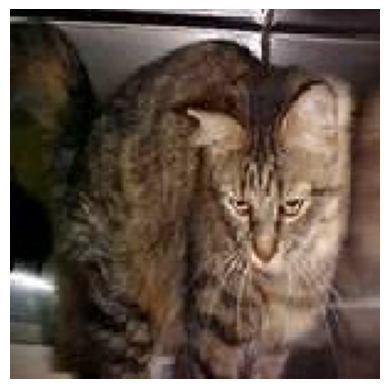

In [28]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

# Đường dẫn thư mục chứa ảnh test trên Google Drive
test_image_folder = '/content/drive/MyDrive/Data_DeepLearning/CNN_DogCat/dogs_vs_cats/test'

# Lấy ảnh đầu tiên trong thư mục
img_name = os.listdir(test_image_folder)[10]
img_path = os.path.join(test_image_folder, img_name)

print('Ảnh đang test:', img_path)

# Load ảnh và resize về đúng kích thước model
img = image.load_img(img_path, target_size=(150, 150))

# Chuyển ảnh thành mảng số
img_array = image.img_to_array(img)

# Chuẩn hóa ảnh về khoảng 0 - 1
img_array = img_array / 255.0

# Thêm chiều batch
img_array = np.expand_dims(img_array, axis=0)

# Dự đoán
result = model.predict(img_array)

print('Giá trị dự đoán:', result[0][0])

if result[0][0] >= 0.5:
    print('Kết quả dự đoán: Dog')
else:
    print('Kết quả dự đoán: Cat')

# Hiển thị ảnh
plt.imshow(img)
plt.axis('off')
plt.show()

Saving anh-cho-20.jpg to anh-cho-20 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Tên ảnh: anh-cho-20 (1).jpg
Giá trị dự đoán: 0.99285537
Kết quả dự đoán: Dog


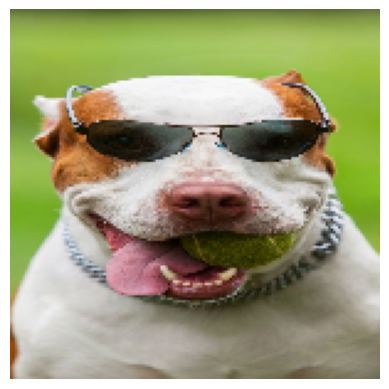

In [37]:
# Upload ảnh từ máy tính lên Colab để test Cat/Dog

from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload file ảnh
uploaded = files.upload()

# Lấy tên file ảnh vừa upload
for file_name in uploaded.keys():
    img_path = file_name

    # Load ảnh và resize về đúng kích thước model đã train
    img = image.load_img(img_path, target_size=(150, 150))

    # Chuyển ảnh thành mảng số
    img_array = image.img_to_array(img)

    # Chuẩn hóa pixel về khoảng 0 - 1
    img_array = img_array / 255.0

    # Thêm chiều batch: (150,150,3) -> (1,150,150,3)
    img_array = np.expand_dims(img_array, axis=0)

    # Dự đoán
    result = model.predict(img_array)

    # In xác suất
    print("Tên ảnh:", file_name)
    print("Giá trị dự đoán:", result[0][0])

    # Phân loại Cat/Dog
    if result[0][0] >= 0.5:
        print("Kết quả dự đoán: Dog")
    else:
        print("Kết quả dự đoán: Cat")

    # Hiển thị ảnh
    plt.imshow(img)
    plt.axis('off')
    plt.show()